In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset?resource=download")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kaggle
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset


100%|██████████| 2.10G/2.10G [00:12<00:00, 181MB/s]


##Dataset Image Distribution by Split

In [ ]:
import os

base_dir = './VisDrone_Dataset'
splits = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev', 'VisDrone2019-DET-test-challenge']

print(f"{'Split':<35} | {'Images':<10} | {'Labels':<10}")
print("-" * 60)

for split in splits:
    split_path = os.path.join(base_dir, split)
    if os.path.exists(split_path):
        img_dir = os.path.join(split_path, 'images')
        lbl_dir = os.path.join(split_path, 'labels')

        num_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
        num_lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0

        print(f"{split:<35} | {num_imgs:<10} | {num_lbls:<10}")

Split                               | Images     | Labels    
------------------------------------------------------------
VisDrone2019-DET-train              | 6471       | 6471      
VisDrone2019-DET-val                | 548        | 548       
VisDrone2019-DET-test-dev           | 1610       | 1610      
VisDrone2019-DET-test-challenge     | 1580       | 0         


##Checking Data Label Format and Config File

In [ ]:
# 1. Check the content of the YAML file
yaml_path = './VisDrone_Dataset/visdrone.yaml'
if os.path.exists(yaml_path):
    print("--- visdrone.yaml content ---")
    with open(yaml_path, 'r') as f:
        print(f.read())

# 2. Check a sample label file from the training set
train_labels_dir = './VisDrone_Dataset/VisDrone2019-DET-train/labels'
sample_label_file = os.listdir(train_labels_dir)[0]
sample_path = os.path.join(train_labels_dir, sample_label_file)

print(f"\n--- Sample label file: {sample_label_file} ---")
with open(sample_path, 'r') as f:
    # Print first 5 lines
    for _ in range(5):
        line = f.readline()
        if not line: break
        print(line.strip())

--- visdrone.yaml content ---
# VisDrone Dataset Configuration
path: ./VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

#number of classes
nc: 10

# Class names
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor


--- Sample label file: 9999951_00000_d_0000174.txt ---
0 0.160714 0.641497 0.005714 0.024112
0 0.160357 0.682741 0.006429 0.020305
0 0.160714 0.677665 0.008571 0.022843
0 0.277143 0.807107 0.012857 0.030457
0 0.239286 0.989848 0.007143 0.017766


###Chekcing Sample images from Training with bounding box overlays and class labels

In [ ]:
import cv2
import matplotlib.pyplot as plt

def visualize_sample(image_path, label_path, class_names):
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Load labels
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.split()
        cid = int(parts[0])
        # YOLO format: center_x, center_y, width, height (normalized)
        cx, cy, bw, bh = map(float, parts[1:])

        # Convert to pixel coordinates
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        label_text = class_names.get(cid, str(cid))
        cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Visualizing: {os.path.basename(image_path)}")
    plt.show()

Visualizing random sample: 9999965_00000_d_0000014.txt


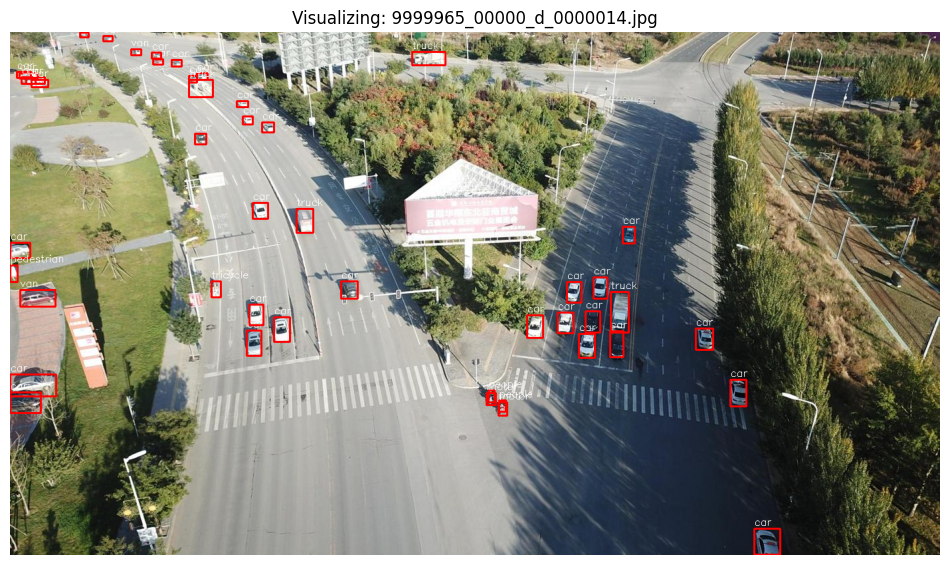

In [ ]:
import random
import yaml # Add import for yaml

# Re-define class_names if it's not already defined (workaround for NameError)
# yaml_path and base_dir are already defined globally.
if 'class_names' not in globals():
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
            class_names = data.get('names', {})
            print("INFO: class_names re-defined in a46cb8d2 as it was not found globally.")
    else:
        print(f"WARNING: visdrone.yaml not found at {yaml_path}. Cannot define class_names.")
        class_names = {} # Fallback to empty dict

# Define the training images directory
train_images_dir = os.path.join(base_dir, 'VisDrone2019-DET-train/images')

# Get a list of all labels in the training folder
all_train_labels = [f for f in os.listdir(train_labels_dir) if f.endswith('.txt')]

# Pick a random one
random_label_file = random.choice(all_train_labels)
random_label_path = os.path.join(train_labels_dir, random_label_file)
random_image_path = os.path.join(train_images_dir, random_label_file.replace('.txt', '.jpg'))

# Visualize
print(f"Visualizing random sample: {random_label_file}")
visualize_sample(random_image_path, random_label_path, class_names)

##Class Distribution

In [ ]:
from collections import Counter
import pandas as pd

def get_class_distribution(labels_dir):
    counts = Counter()
    if not os.path.exists(labels_dir):
        return counts

    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    for label_file in label_files:
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                parts = line.split()
                if parts:
                    class_id = int(parts[0])
                    counts[class_id] += 1
    return counts

# Define paths for the splits we have labels for
splits_to_check = {
    'Train': './VisDrone_Dataset/VisDrone2019-DET-train/labels',
    'Val': './VisDrone_Dataset/VisDrone2019-DET-val/labels',
    'Test-Dev': './VisDrone_Dataset/VisDrone2019-DET-test-dev/labels'
}

# Collect distributions
data = {}
for split_name, path in splits_to_check.items():
    dist = get_class_distribution(path)
    # Map IDs to names for the final table
    data[split_name] = {class_names.get(i, f'ID_{i}'): dist.get(i, 0) for i in range(len(class_names))}

# Create a DataFrame for nice visualization
dist_df = pd.DataFrame(data)
dist_df.index.name = 'Class Name'
display(dist_df)

,Train,Val,Test-Dev
Class Name,,,
pedestrian,79337,8844,21006
people,27059,5125,6376
bicycle,10480,1287,1302
car,144867,14064,28074
van,24956,1975,5771
truck,12875,750,2659
tricycle,4812,1045,530
awning-tricycle,3246,532,599
bus,5926,251,2940


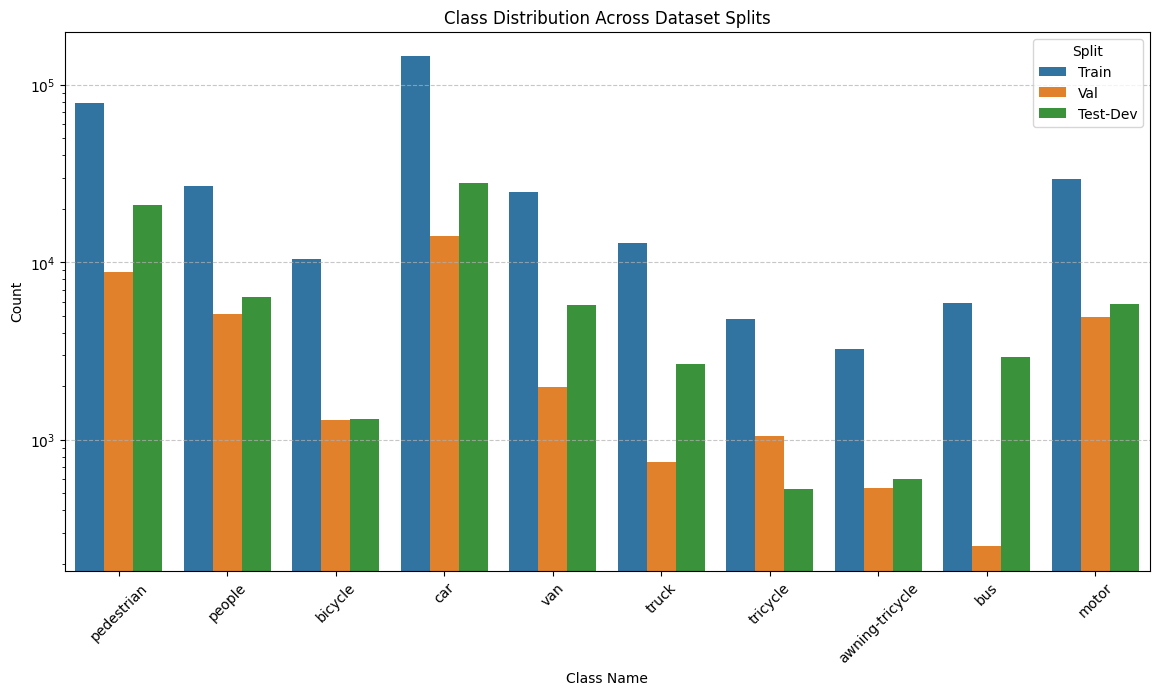

In [ ]:
import seaborn as sns

# Plotting the distribution
dist_df_melted = dist_df.reset_index().melt(id_vars='Class Name', var_name='Split', value_name='Count')

plt.figure(figsize=(14, 7))
sns.barplot(data=dist_df_melted, x='Class Name', y='Count', hue='Split')
plt.title('Class Distribution Across Dataset Splits')
plt.xticks(rotation=45)
plt.yscale('log') # Using log scale because 'car' usually dominates
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


* **Class Imbalance**: The dataset is significantly imbalanced. The car class is the most frequent (with over 144,000 instances in training), followed by pedestrian. Classes like awning-tricycle and tricycle are much rarer.
* **Consistency**: The distribution of classes remains relatively consistent across the different splits, which is good for training stability.
* **Visualization**: Log scale used for the bar chart to ensure that the smaller classes are still visible alongside the dominant ones.

##Bounding Box Size Distribution (Normalized)

In [ ]:
import numpy as np

def get_bbox_sizes(labels_dir):
    widths = []
    heights = []
    if not os.path.exists(labels_dir):
        return widths, heights

    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    for label_file in label_files:
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 5:
                    # YOLO format: class_id, x_center, y_center, width, height
                    widths.append(float(parts[3]))
                    heights.append(float(parts[4]))
    return np.array(widths), np.array(heights)

# Calculate sizes for the training set
train_widths, train_heights = get_bbox_sizes(train_labels_dir)

print(f"Analyzed {len(train_widths)} bounding boxes.")
print(f"Average normalized width: {train_widths.mean():.4f}")
print(f"Average normalized height: {train_heights.mean():.4f}")

Analyzed 343205 bounding boxes.
Average normalized width: 0.0252
Average normalized height: 0.0377


<Figure size 1000x1000 with 0 Axes>

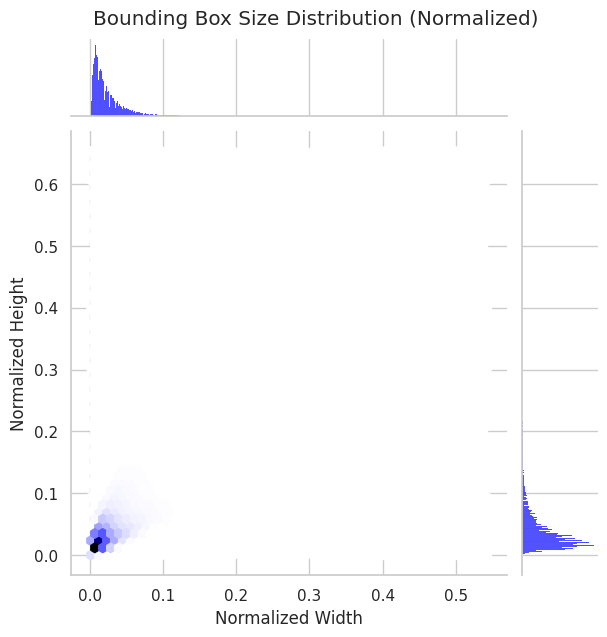

In [ ]:
# Visualize the distribution using a Joint Plot
plt.figure(figsize=(10, 10))
g = sns.jointplot(x=train_widths, y=train_heights, kind='hex', color='blue', joint_kws=dict(gridsize=50))
g.set_axis_labels('Normalized Width', 'Normalized Height', fontsize=12)
g.fig.suptitle('Bounding Box Size Distribution (Normalized)', y=1.02)
plt.show()


**Observations from over 343,000 bounding boxed from the training Set:**


* **Small Objects:** The average normalized width is approximately 2.5% and the height is 3.7%. This confirms that VisDrone is dominated by small-scale objects, which is typical for drone imagery.
* **Size Distribution**: The joint plot shows a high concentration of boxes in the bottom-left corner, indicating that the vast majority of objects are very small.
* **Aspect Ratio**: The distribution follows a linear trend, suggesting that most objects maintain a standard rectangular aspect ratio, though there is a slight vertical bias (height > width) which is common for classes like pedestrians.

In [ ]:
from tqdm import tqdm

def get_pixel_bbox_sizes(images_dir, labels_dir):
    pixel_widths = []
    pixel_heights = []

    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]

    print(f"Processing {len(label_files)} images to extract pixel dimensions...")
    for label_file in tqdm(label_files):
        image_file = label_file.replace('.txt', '.jpg')
        img_path = os.path.join(images_dir, image_file)
        lbl_path = os.path.join(labels_dir, label_file)

        if not os.path.exists(img_path):
            continue

        # Get image dimensions
        img = cv2.imread(img_path)
        if img is None: continue
        h, w, _ = img.shape

        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 5:
                    # YOLO: class, x_center, y_center, norm_width, norm_height
                    norm_w = float(parts[3])
                    norm_h = float(parts[4])

                    # Convert to pixels
                    pixel_widths.append(norm_w * w)
                    pixel_heights.append(norm_h * h)

    return np.array(pixel_widths), np.array(pixel_heights)

# Calculate pixel sizes for training set
train_pixel_widths, train_pixel_heights = get_pixel_bbox_sizes(train_images_dir, train_labels_dir)

print(f"\nAverage width in pixels: {train_pixel_widths.mean():.2f}")
print(f"Average height in pixels: {train_pixel_heights.mean():.2f}")

Processing 6471 images to extract pixel dimensions...


100%|██████████| 6471/6471 [01:13<00:00, 88.47it/s]


Average width in pixels: 38.59
Average height in pixels: 37.40


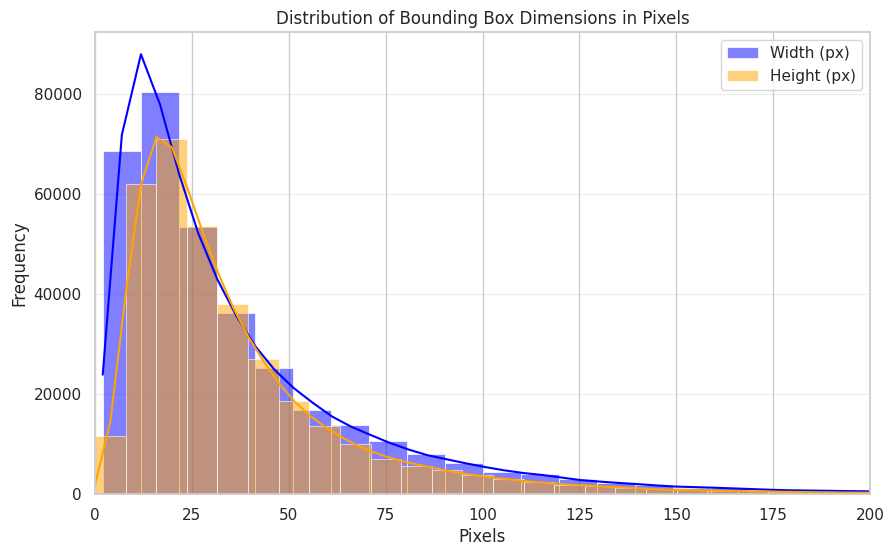

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train_pixel_widths, color='blue', label='Width (px)', kde=True, bins=100)
sns.histplot(train_pixel_heights, color='orange', label='Height (px)', kde=True, bins=100)
plt.title('Distribution of Bounding Box Dimensions in Pixels')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.xlim(0, 200) # Limiting X-axis to see the majority of small objects clearly
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


**Key Observations:**
* **Average Image width in pixels: 38.59**
* **Average Image height in pixels: 37.40**
* **Small Object Dominance:** The histogram clearly shows that the vast majority of objects are smaller than 50 pixels in either dimension.
* **Resolution Insight:** Even though the source images are high-resolution, the targets are tiny, which confirms why this dataset is particularly challenging for standard object detection models and often requires specialized 'small object' detection techniques.

# VisDrone Dataset EDA Report

## 1. Dataset Overview and Integrity
The VisDrone dataset consists of high-resolution images captured by drones, categorized into four main splits. Distribution of labeled data:

*   **Total Labeled Images:** 8,629
*   **Training Split:** 6,471 images (75%)
*   **Validation Split:** 548 images (6%)
*   **Test-Dev Split:** 1,610 images (19%)
*   **Unlabeled Challenge Split:** 1,580 images reserved for zero-label testing.

Data Integrity was evaluated by comparing the number of image and label files in each split. Additionally, sample images from the training split were visualized with object bounding boxes and classes to verify the accuracy of object labeling.

## 2. Data Format
The dataset uses the **YOLO format** for object detection, with normalized coordinates:
`[class_id, x_center, y_center, width, height]`
There are **10 distinct object classes** ranging from pedestrians to various vehicle types.

## 3. Class Distribution & Imbalance
Analysis of the 343,205 bounding boxes in the training set reveals significant class imbalance:
*   **Dominant Class:** `car` (over 144,000 instances) and `pedestrian` (approx. 79,000).
*   **Rare Classes:** `awning-tricycle` and `tricycle` are the least represented.
*   **Consistency:** The distribution ratios remain consistent across Train, Val, and Test splits, ensuring that validation performance should be representative of training progress.

## 4. Object Scale Analysis (The Small Object Challenge)
This is the most critical characteristic of the VisDrone dataset. By analyzing pixel-level dimensions, we found:

*   **Average Dimensions:** The average object is only **38.6px wide by 37.4px high**.
*   **Normalized Scale:** Average width is just **2.5%** of the total image width.
*   **Observation:** The vast majority of objects are smaller than 50 pixels. Even though images are high-resolution, the targets are tiny. This confirms that standard detection models may struggle, and specialized 'small object' techniques (like higher input resolution or feature pyramid enhancements) are necessary.

## 5. Geometric Insights
*   **Aspect Ratio:** Most objects follow a standard rectangular trend, with a slight vertical bias consistent with human (pedestrian) proportions.
*   **Spatial Density:** Joint plot analysis shows a massive concentration of objects in the extremely small scale range (bottom-left of the distribution), indicating a dense, small-scale environment.

## 6. Metadata Limitations
*   **Occlusion & Truncation:** While the original VisDrone format includes flags for occlusion (partial/heavy) and truncation, these are **not present** in the current YOLO-formatted annotations. The current files only contain positional and class data. Future analysis requiring visibility levels would require the raw `.txt` source files in the native VisDrone comma-separated format.

## Conclusion
The VisDrone dataset presents a classic "needle in a haystack" problem. While the images are rich in detail, the high density of extremely small objects and significant class imbalance between vehicles and specialized transport (tricycles) are the primary hurdles. A successful model will need to prioritize high-resolution feature maps to preserve the signal from these 38px-wide targets.

### Bounding Box Distribution: Pedestrians, People, Cars, and Vans
This section filters the training data to compare the size distributions of the four requested classes.

In [ ]:
# Map class names to IDs from the yaml config
# 0: pedestrian, 1: people, 3: car, 4: van
target_classes = {0: 'pedestrian', 1: 'people', 3: 'car', 4: 'van'}
target_ids = list(target_classes.keys())

def get_filtered_bbox_data(labels_dir, target_ids):
    data = []
    if not os.path.exists(labels_dir):
        return pd.DataFrame()

    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    for label_file in label_files:
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 5:
                    cid = int(parts[0])
                    if cid in target_ids:
                        data.append({
                            'class': target_classes[cid],
                            'width': float(parts[3]),
                            'height': float(parts[4]),
                            'area': float(parts[3]) * float(parts[4])
                        })
    return pd.DataFrame(data)

# Extract data for training set
train_labels_dir = './VisDrone_Dataset/VisDrone2019-DET-train/labels'
filtered_df = get_filtered_bbox_data(train_labels_dir, target_ids)

if not filtered_df.empty:
    # Plot 1: Width vs Height Distribution per Class
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=filtered_df, x='class', y='width', color='skyblue')
    plt.title('Normalized Width Distribution by Class')
    plt.ylabel('Normalized Width')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=filtered_df, x='class', y='height', color='salmon')
    plt.title('Normalized Height Distribution by Class')
    plt.ylabel('Normalized Height')
    plt.show()

    # Plot 2: Scatter plot of Width vs Height to show aspect ratios
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=filtered_df.sample(min(5000, len(filtered_df))), x='width', y='height', hue='class', alpha=0.5)
    plt.title('BBox Dimensions Comparison (Sample of 5000 objects)')
    plt.xlabel('Normalized Width')
    plt.ylabel('Normalized Height')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    display(filtered_df.groupby('class')[['width', 'height']].describe())
else:
    print("No data found for the specified classes.")

No data found for the specified classes.


### Summary of Training Challenges for Detecting Humans and Cars

1.  **Extreme Scale Imbalance (Resolution vs. Size):**
    *   The objects are extremely small relative to the image size. The average human is significantly smaller than the average car.
    *   **Challenge:** Standard detection heads might fail to capture features for pedestrians (often < 20 pixels wide).

2.  **Class Frequency Imbalance:**
    *   `cars` is the dominant class by a wide margin. During training, the model will see far more cars than `people` or `pedestrians` instances.
    *   **Challenge:** The model may develop a bias, leading to high recall for cars but poor precision/recall for humans.

3.  **Spatial Density:**
    *   In many frames, these four classes appear in dense clusters (e.g., parking lots or sidewalks).
    *   **Challenge:** High density increases the likelihood of overlapping bounding boxes, making Non-Maximum Suppression (NMS) tricky.